# Section 1: Summary and Introduction
This iPython notebook describes the creation of an environment that interacts with the `Turtlebot3_Assessment2` Gazebo world and proposes two different Reinforcement Learning methodologies to help a "Turtlebot" (i.e. the Agent) reach one of two the goals in the environment.

The two models proposed are:
1) A Linear Approximation Function using the provided `trueSarsaλ` class
2) An Actor-Critic (Policy Gradient) Neural Network model

As this report demonstrates, the trueSarsaλ model was able to reach convergence within a 30-50 episodes, while the Actor-Critic method was unable to reach convergence.

# Section 2: Creating a suitable `Env` Class
An environment class `Env_TurtlebotAssessment2` was created by building on the example provided in `Lesson16_RL_Robot_Navigation.ipynb`.

The class sets up a Turtlebot with three actions (forward, left, right) and stops it after each action (discretizing the actions). The environment also rewards the agent for being in specific states (reaching goal, hitting wall, moving forward, turning left/right) as well as by its distance from the targets (the further away from the goal, the more negative the reward). The state is represented simply by the readings from the LaserScan `/scan` message, with some minor transformations (rounding and normalizing).

In [1]:
# Dependencies for creating Environment and interacting with ROS2
import rclpy as ros
from rclpy.node import Node
from sensor_msgs.msg import LaserScan
import numpy as np
from numpy import Inf
from geometry_msgs.msg import Twist
from nav_msgs.msg  import Odometry
from std_srvs.srv import Empty
import random
from math import atan2, pi
import matplotlib.pyplot as plt
import time

ros.init()

In [2]:
class Env_TurtlebotAssessment2(Node):
    # Initialisation
    def __init__(self, name='ActionPublisher_StateSubscriber'
                 , frequency=0.01, n_spins = 64
                 , speed_linear=0.5, speed_angular=0.25
                 , n_beams = 60
                 , rewards = [10,-10, 0, -1], distance_reward_scaler=1.0):
        super().__init__(name)
        self.get_logger().info('Environment Initialised')

        self.n_sigfigs = 4                  # Number of significant figures to round to for ease of debugging / reading
        self.n_spins = n_spins              # Number of times to spin (brute-force asynchronized messages)
        
        # Variables for debugging n_spins and asynchornous messages
        self.n_action_executes = 0          # Counting the number of executions per test iteration
        self.n_stop_executes = 0            # Counting the number of stop-action executions

        # Rewards for the robot
        self.distance_reward_scaler = distance_reward_scaler    # Allowing the distance-based rewards to be adjusted
        self.rewards = rewards
        self.cumulative_reward = 0

        # Initialising pose and movements
        # Basic default values for movement
        self.speed_linear = speed_linear    # Linear speed in m/s
        self.speed_angular = speed_angular  # Angular speed in rad/s
        self.action = 0                     # Default action set to "stop"
        self.robot = Twist()                # Twist object

        self.estimated_pose = np.zeros(3)   # [x=0, y=0, yaw=0]
        self.t = 0

        # Dictionary of actions - used for debugging messages
        self.actions_list = {-2:'stop (for reset)'
                        , -1:'reverse'
                        , 0:'forward'
                        , 1:'turn left'
                        , 2:'turn right'}
        
        # Defining goals in environment
        self.goal_zone_radius = 0.6                                         # 2 feet == 0.6 metres
        self.goal_coordinates = np.array([[2,2], [-2,-2]])                  # Goal coordinates
        self.n_goals = self.goal_coordinates.shape[0]
        self.goal_distance = np.ones(self.n_goals)*Inf                      # Initial distance to goals
        self.euclid_distances_from_goals = np.ones(self.n_goals)*Inf        # Initial linear distances to goals
        self.angular_distances_from_goals = np.ones(self.n_goals)*Inf       # Initial angular distances to goals

        # Measures used to track success
        self.n_achieved_goals = 0                                           # Number of times we achieved the goal (in total)
        self.n_hit_wall_this_ep = 0                                         # Number of times the agent hit the wall this episode
        
        # Publishers
        self.controller = self.create_publisher(Twist, '/cmd_vel', 0)       # Publishes /cmd_vel messages
        self.timer = self.create_timer(frequency, self.control)             # Triggers self.controller to publish
        
        # Subscriptions
        self.odometer = self.create_subscription(Odometry, '/odom'
                                                 , self.odom_callback, 0)   # Receives Odometry
        self.scanner = self.create_subscription(LaserScan, '/scan'
                                                , self.scan, 0)             # Receives LDS messages

        # LaserScans:
        # Default settings for scanner (in metres)
        self.range_max = 3.50   # Gazebo world is at least 4mx4m based on goal locations
        self.range_min = 0.25   # Any lower and turtlebot is at risk of flipping at higher velocities
        
        self.n_beams = n_beams                                  # For future use in feature selection
        self.scans = np.ones(n_beams)*self.range_max

        # Defining compatibility measures
        # Number of Actions
        self.nA = len(self.actions_list)-2                      # Removing the "reverse" action and reset "stop" action

        # Defining state-space for one-hot encoding the state-space (experimenting)
        world_n_rows = world_n_cols = 20
        world_n_directions = n_beams                            # Default turn-speed is .5 rads/s
        self.nS = world_n_rows*world_n_cols*world_n_directions
        self.state_space = np.zeros((self.nS, self.n_beams))    # Creating a matrix to track states we have visited
        self.s = np.zeros(self.nS)                              # Placeholder for one-hot encoded state

        self.world_length = 4                                   # In metres
        self.state_length = self.world_length/world_n_rows      # This will be the tolerance of a scan to switch between on state and another

        # Creating a service client to reset the model pose
        self.reset_pose_client = self.create_client(Empty, "/reset_world")
        while not self.reset_pose_client.wait_for_service():
            self.get_logger().info("'reset_world' service not ready yet - waiting a bit longer ...")
        
        # Compatibility
        self.Vstar = None

    # Method to reset the model's pose (location + orientation)
    def reset_model_pose(self):
        self.reset_pose_client.call_async(Empty.Request())
        time.sleep(.25)                                           # to wait for any potential reset glitches. this avoids adding to the cumulative reward
        self.reset_pose_client.call_async(Empty.Request())
        self.get_logger().info("Model Pose Reset")
    
    # Reset method with new name for compatibility purposes
    def reset(self):
        self.reset_model_pose()
        return self.s_()

    # Defining a method to flush messages
    def spin_n_times(self, n_spins=1):
        for _ in range(n_spins): ros.spin_once(self)


    # ------------------------------------------------ #
    # >> Actions related methods
    # ------------------------------------------------ #
    # Defining function to make robot take an action
    def step(self, action):
        #self.get_logger().info(f'Entered into "step" method with action: {action}')
        self.action = action

        speed_linear = speed_angular = 0.0                  # Changing default values
        match self.action:
            case -1: speed_linear = -self.speed_linear      # Reverse
            case  0: speed_linear = self.speed_linear       # Forward
            case  1: speed_angular = self.speed_angular     # Left
            case  2: speed_angular = -self.speed_angular    # Right
            case  _: speed_linear = speed_angular = 0.0     # Unrecognised action == stop
        
        self.robot.linear.x = speed_linear                  # Setting linear speed in Twist message
        self.robot.angular.z = speed_angular                # Setting angular speed in Twist message

        self.spin_n_times(self.n_spins)
        self.n_action_executes += 1
        
        self.stop()                                         # Stopping after taking an action
        self.spin_n_times(self.n_spins//2)                  # Fewer spins required to stop

        # Calculate reward and special states after stopping
        reward, done, wall = self.reward(self.action)
        reward = round(reward, self.n_sigfigs)
        self.cumulative_reward += reward                    # Debugging purposes
        #self.get_logger().info(f'Reward: {reward}, Cumulative Reward: {self.cumulative_reward}')

        # Returning in specific format for compatibility
        return self.s_(), reward, done, {}

    # Defining a stop function
    def stop(self):
        #self.get_logger().info('Entered into "stop" method')
        self.robot.linear.x = 0.0
        self.robot.angular.z = 0.0

    # Defining the action-message (i.e. Twist message) to be published
    def control(self):
        #self.get_logger().info(f'Entered into "control" method with action: {self.action}')
        self.controller.publish(self.robot)                 # Publish Twist message

    # ------------------------------------------------ #
    # >> State-related methods
    # ------------------------------------------------ #
    # Retrieve scan data
    def scan(self, scans):
        scans = np.array(scans.ranges)                      # Create numpy array that is same size as the scanner's results array
        scans[scans==Inf] = self.range_max                  # Cap the maximum range numbers received
        self.scans = scans
    
    # Returning (default) state representation
    def s_(self):
        rounded_scans = np.round(self.scans, 1)
        return rounded_scans/rounded_scans.sum()
    
    # ------------------------------------------------ #
    # >> Reward-related methods
    # ------------------------------------------------ #
    # Retrieve Odometer pose-data to calculate the distance to goal(s)
    def odom_callback(self, odom_reading):
        self.odom_reading = odom_reading

        # Converting from quarternion orientation to Euler representation
        # gives yaw = angle from 0 (straight forward) that the robot is positioned in
        orientation = self.odom_reading.pose.pose.orientation
        x,y,z,w = orientation.x, orientation.y, orientation.z, orientation.w
        yaw = atan2(2.0*(x*y + w*z), w*w + x*x - y*y - z*z)     # lifted from provided Lesson16 code

        # [linear_x_coord, linear_y_coord, yaw_angle]
        self.estimated_pose[0] = self.odom_reading.pose.pose.position.x
        self.estimated_pose[1] = self.odom_reading.pose.pose.position.y
        self.estimated_pose[2] = yaw

        # Update distances with latest odom readings
        self.euclid_distances_from_goals = self.linear_distance_from_goal(self.goal_coordinates)
        self.angular_distances_from_goals = self.angular_distance_from_goal(self.goal_coordinates)

    # Finding the Euclidean Distance from the robot to the goals (metres)
    def linear_distance_from_goal(self, goal_coordinates):
        goal_distances = np.zeros(self.n_goals)
        for i, goal in enumerate(goal_coordinates):
            goal_distances[i] = np.sqrt((goal[0] - self.estimated_pose[0])**2       # x
                                        + (goal[1] - self.estimated_pose[1])**2)    # y
        return goal_distances.round(self.n_sigfigs)
    
    # Finding the Angular Distances between the robot and the goals (radians)
    def angular_distance_from_goal(self, goal_coordinates):
        angular_distances = np.zeros(self.n_goals)

        # Robot orientation
        yaw = self.estimated_pose[2]
        if yaw < 0: yaw += 2*pi             # Positive numbers only
        #self.get_logger().info(f'yaw: {yaw}')

        # Finding the angle between the goal and the robot (radians)
        for i, goal in enumerate(goal_coordinates):
            angle_to_goal = atan2((abs(self.estimated_pose[0] - goal[0])),       # x
                                    (abs(self.estimated_pose[1] - goal[1])))     # y

            # Angle between robot and goal
            angular_distances[i] = abs(yaw - angle_to_goal)

        angular_distances[1] -= pi
        #self.get_logger().info(f'angular_distances: {angular_distances}')
        return abs(angular_distances.round(self.n_sigfigs))

    # Checking to see if we are within the goal-zone
    def at_goal(self):
        at_goal = np.where(self.euclid_distances_from_goals <= self.goal_zone_radius)[0].shape[0] > 0
        if at_goal:
            print(f'!!!! Goal Reached !!!!')
            
        return at_goal
    
    # Checking to see if we are too close to the wall
    def hit_wall(self):
        # We are only looking in a ~90 degree forward cone
        n_forward_beams = int(self.scans.shape[0] // 4 // 2)
        forward_scans = np.concatenate((self.scans[-n_forward_beams:],
                                       self.scans[:n_forward_beams]))

        if forward_scans.min() < self.range_min: 
            wall_dist = forward_scans.min()
            self.get_logger().info(f'Hit the wall! Distance to wall: {np.round(wall_dist, 4)}')
            self.reset_model_pose()
        
        return forward_scans.min() < self.range_min
    
    # Defining the reward to be returned to the robot after each step
    def reward(self, action):
        # Reward differently depending on whether it is at goal, hitting a wall, or
        #  going forward or taking some other action (we want to reward forward movement more)
        # Based on code from provided Lesson16 notebook
        state_type = [self.at_goal(), self.hit_wall(), action==0, action!=0].index(True)
        reward = self.rewards[state_type]

        self.goal_distance = ((self.euclid_distances_from_goals) + \
                                (self.angular_distances_from_goals))*self.distance_reward_scaler
        
        #self.get_logger().info(f'Rewards: state: {reward} + dist: {-np.min(self.goal_distance).round(2)}')
        
        # Affect the "baseline" rewards by the negative of the distance to the closest goal
        if state_type: reward -= np.min(self.goal_distance)

        if state_type==0: self.n_achieved_goals += 1

        if state_type == 1:
            self.n_hit_wall_this_ep += 1
            self.reset_model_pose()
        
        # Return the reward, whether it has reached the goal, and whether it has hit the wall
        return reward, state_type==0, state_type==1
     
    # ------------------------------------------------ #
    # >> Debuggina and compatibility methods
    # ------------------------------------------------ #
    def get_scans(self):
        ros.spin_once(self)
        return self.scans

    def get_pose(self):
        ros.spin_once(self)
        return self.odom_reading
    
    def render(self, **kw):
        pass


# Section 3: Model 1 - Action Value-Function with Linear Function Approximation

The `reward()` function used adjusts rewards based on the Turtlebot's state, with differing rewards given for reaching the goal (very large positive reward), hitting a wall (large negative reward), moving forward (no reward), and turning left or right (small negative reward). Additionally, the agent is penalised based on its distance (linear and angular) to the closest goal, with larger distances resulting in greater negative rewards. This structure promotes exploration in the direction of a goal and dis-incentivizes taking too long to reach a goal.

The `at_goal` reward is much larger to help the 'signal' cut-through the negative reward noise.

In [3]:
from RLv import *

In [4]:
# Defining comparison function to help with hyperparameter search / tuning
def plot_compare(models, labels):
    plt.figure(figsize=(12,5))

    for i in range(len(labels)):
        # Plotting Number of Steps per episode
        plt.subplot(1,2,1).plot(models[i].Ts, '-')
        plt.subplot(1,2,1).set_xlabel('Episode')
        plt.subplot(1,2,1).set_ylabel('Steps')
        plt.subplot(1,2,1).set_title('Steps per Episode')

        # Plotting episode rewards per episode
        plt.subplot(1,2,2).plot(models[i].Rs, '--', label=f'{labels[i]}')
        plt.subplot(1,2,2).set_xlabel('Episode')
        plt.subplot(1,2,2).set_ylabel('Cumulative Reward')
        plt.subplot(1,2,2).set_title('Cumulative Reward per Episode')
        
    plt.legend()
    plt.show

In [3]:
# Defining a variant of the "base" environment for ease of testing and debugging
class Env_LFA(Env_TurtlebotAssessment2):
    def __init__(self, nF=60, **kw):
        self.nF = nF
        super().__init__(**kw)
    
    def s_(self):
        # Discretizing to the nearest 0.1 metres
        φ = np.round(self.scans, 1)
        
        # Putting heavier weighting on the front sensors (~60 degree cone in front)
        # Assumption is that what's in front is more important than what's to the sides / back
        front_beams = int(np.round(60/360 * self.nF, 0))
        front_weights = 2.0     # Front beams are worth twice as much
        φ[:front_beams//2] *= front_weights
        φ[-front_beams//2:] *= front_weights

        return φ/φ.sum()    # Normalizing features
    
    
    # Defining a one-hot encoded feature vector
    def S_(self):
        return np.eye(self.nF)

## Hyper-parmeter tuning

In [5]:
# Instantiating environment for Linear Function Approximation
# Environment moves faster to help speed training
env_lfa_test = Env_LFA(frequency = 1/25, n_spins=15, nF=60
                       , speed_linear = .7, speed_angular = 0.5*pi
                       , distance_reward_scaler = 1.0, rewards = [50, -10, 0, -1])

[INFO] [1715021530.773703527] [ActionPublisher_StateSubscriber]: Environment Initialised


In [6]:
# Setting max_t and episodes
# For hyperparameter tuning we will set this to a lower number
max_t = 500
episodes = 50

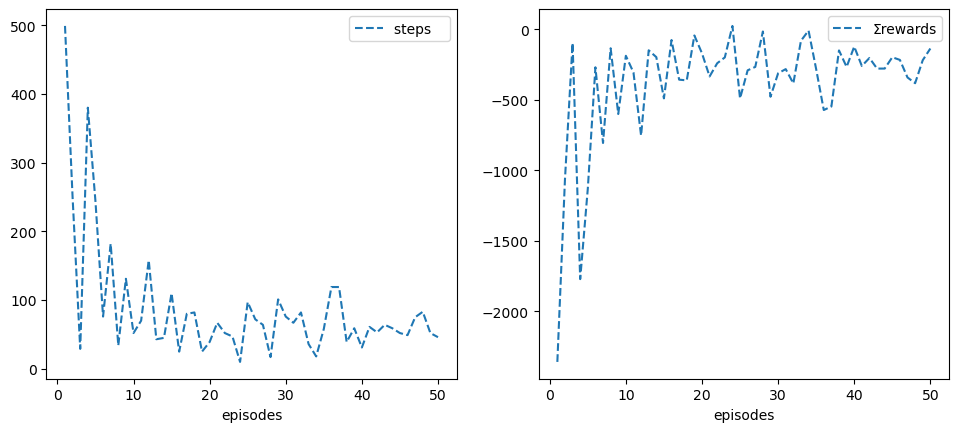

In [8]:
# Testing two different Sarsa with Eligibility Trace methodologies
trueSarsaλ = trueSarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, seed=1, γ=.9, λ=.7, α=.4, **demoGame()).interact()
sarsaλ = Sarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, seed=1, γ=.9, λ=.7, α=.4, **demoGame()).interact()

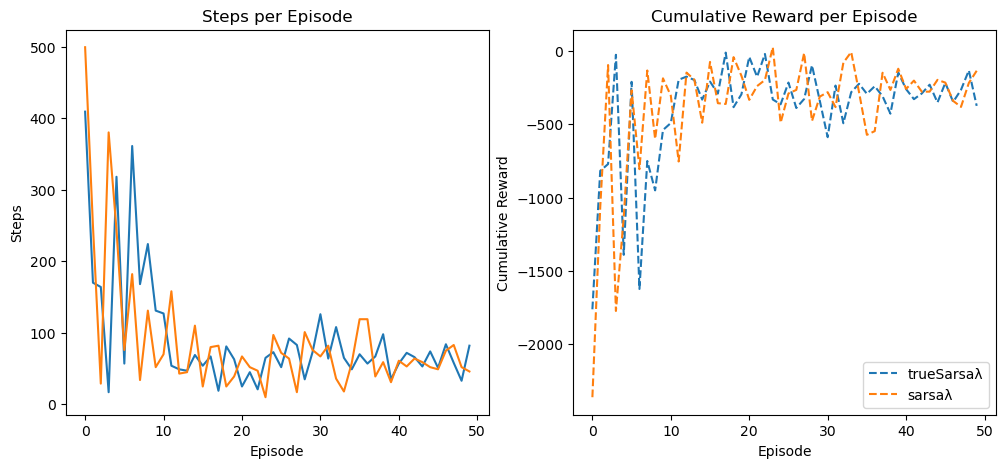

In [9]:
# Directly comparing models shows that trueSarsaλ may be more performant
plot_compare(models=[trueSarsaλ, sarsaλ], labels=['trueSarsaλ', 'sarsaλ'])

In [9]:
# Redefining trueSarsaλ to include success tracking metrics
class tracking_trueSarsaλ(MDP):
    def __init__(self, λ=.5, **kw):
        super().__init__(**kw)
        self.λ = λ
        self.step = self.step_an # for Sarsa we want to decide the next action in time step t
        
        self.ep_tracker = 0
        self.n_wall_hits = np.zeros(self.episodes)
        
    def step0(self):
        self.Z = self.W*0
        self.qo = 0
    # ----------------------------------------🌖 online learning ----------------------------------------
    def online(self, s, rn,sn, done, a,an):
        # Adding logic to include success tracking
        if self.ep_tracker != self.ep:
            self.n_wall_hits[self.ep_tracker] = self.env.n_hit_wall_this_ep
            print(f'Last episde we hit the wall {self.env.n_hit_wall_this_ep} time(s)')
            self.env.n_hit_wall_this_ep = 0
            self.ep_tracker = self.ep

        α, γ, λ = self.α, self.γ, self.λ
        
        self.q = self.Q(s,a)
        self.qn= self.Q(sn,an)*(1-done)
        δ = rn + γ*self.qn - self.q
        self.Z[a] = λ*γ*self.Z[a] + (1-α*λ*γ*self.Z[a].dot(s))*s
        
        self.W[a] += α*(δ + self.q - self.qo )*self.Z[a] - α*(self.q - self.qo)*s

        self.qo = self.qn

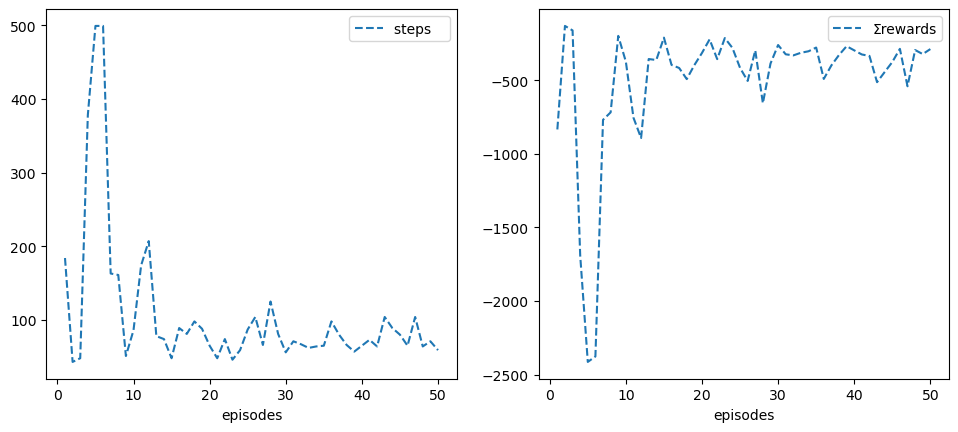

In [11]:
# Comparing types of ε-greedy decay methods (no exponential-only decay due to limited testing time)
lin_decay_trueSarsaλ = tracking_trueSarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, dε=1., seed=1, γ=.9, λ=.7, α=.4, **demoGame()).interact()
both_decay_trueSarsaλ = tracking_trueSarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, dε=.99, seed=1, γ=.9, λ=.7, α=.4, **demoGame()).interact()

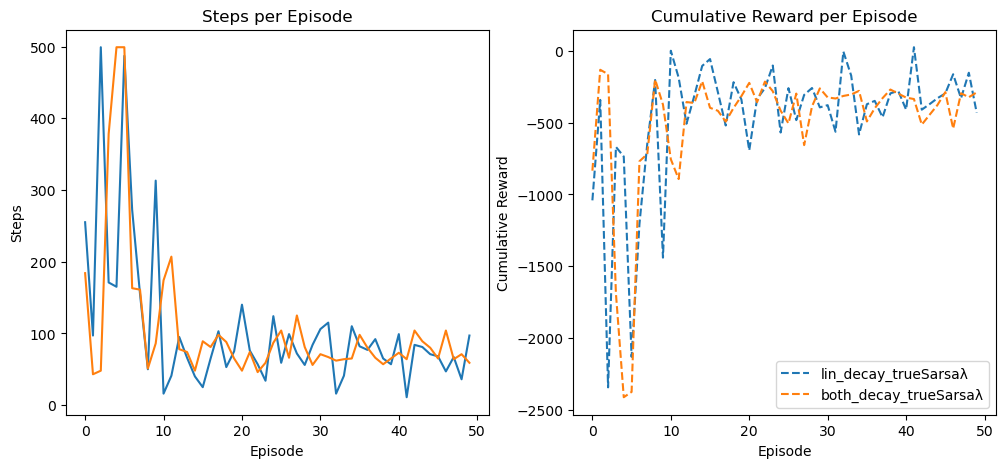

In [12]:
plot_compare(models=[lin_decay_trueSarsaλ, both_decay_trueSarsaλ]
             , labels=['lin_decay_trueSarsaλ', 'both_decay_trueSarsaλ'])

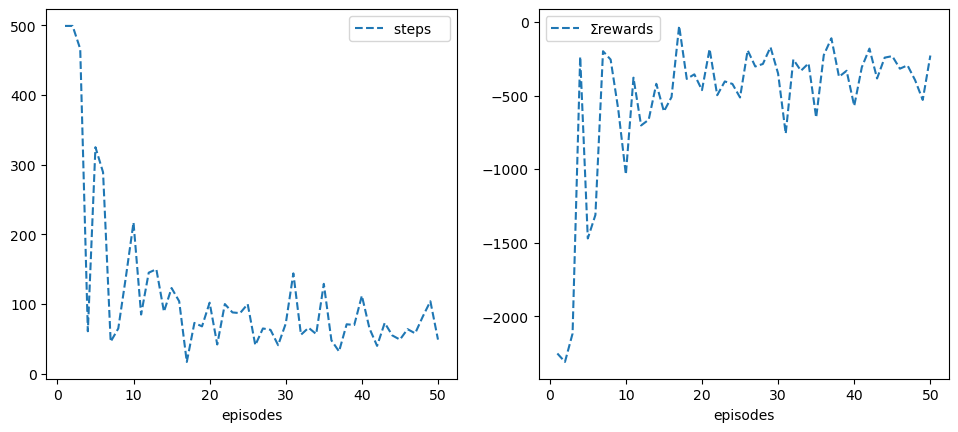

In [13]:
# Comparing different levels of future-reward discounting
trueSarsaλ_6γ = tracking_trueSarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, dε=.99, seed=1, γ=.6, λ=.7, α=.4, **demoGame()).interact()
trueSarsaλ_8γ = tracking_trueSarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, dε=.99, seed=1, γ=.8, λ=.7, α=.4, **demoGame()).interact()
trueSarsaλ_9γ = tracking_trueSarsaλ(env=env_lfa_test, max_t=max_t, episodes=episodes, dε=.99, seed=1, γ=.9, λ=.7, α=.4, **demoGame()).interact()

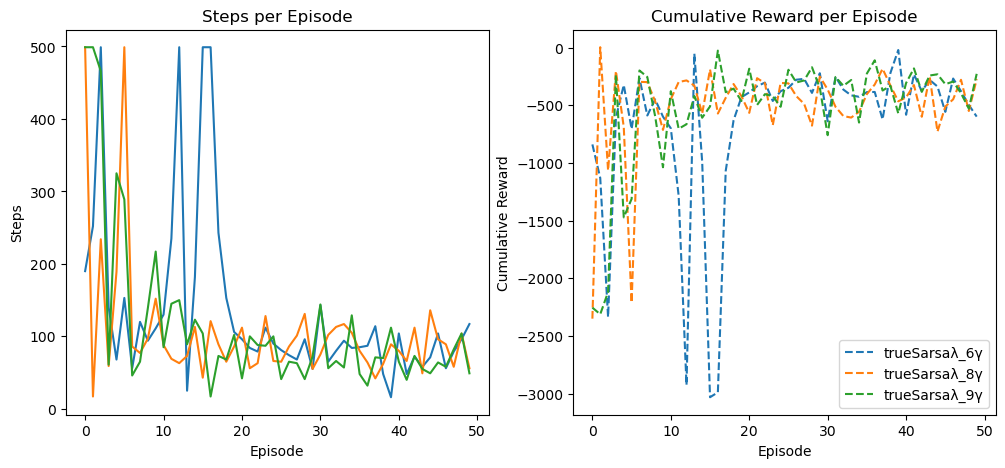

In [14]:
plot_compare(models=[trueSarsaλ_6γ, trueSarsaλ_8γ, trueSarsaλ_9γ]
             , labels=['trueSarsaλ_6γ', 'trueSarsaλ_8γ', 'trueSarsaλ_9γ'])

In [21]:
# Comparing different lambdas and alphas for varying step sizes and eligibility trace strength
def compare_lambda_alphas(max_t=1000, episodes=50, seed=1, lambda_alphas = [(.6,.1)]):
    episode_steps = []
    episode_rewards = []
    
    for hyper_params in lambda_alphas:
        λ = hyper_params[0]
        α = hyper_params[1]
        print(f'----------------------------')
        print(f'Running with λ:{λ} and α: {α}')
        print(f'----------------------------')
        
        # Reset trueSarsa-lambda MDP
        multirun_trueSarsaλ = tracking_trueSarsaλ(env=env_lfa_test
                                                , max_t=max_t, episodes=episodes
                                                , seed=seed, λ=λ, α=α).interact()
        episode_steps.append(multirun_trueSarsaλ.Ts)
        episode_rewards.append(multirun_trueSarsaλ.Rs)
        multirun_trueSarsaλ.env.reset()

    return episode_steps, episode_rewards

In [22]:
lambda_alphas = [(.7,.4), (.8, .3), (.9, .2)]
steps, rewards = compare_lambda_alphas(max_t=max_t, episodes=episodes, lambda_alphas=lambda_alphas)

----------------------------
Running with λ:0.7 and α: 0.4
----------------------------


[INFO] [1714978752.633011128] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978760.608754014] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.23250000178813934
[INFO] [1714978760.861743751] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978761.114784157] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978772.728773843] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.12120000272989273
[INFO] [1714978772.982156877] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978773.235176662] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978794.288676879] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.11999999731779099
[INFO] [1714978794.542044983] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978794.795231251] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714978805.168799811] [ActionPublisher_StateSubscriber]: Hit the wa

!!!! Goal Reached !!!!


[INFO] [1714978843.539700126] [ActionPublisher_StateSubscriber]: Model Pose Reset


Last episde we hit the wall 10 time(s)


...

[INFO] [1715000080.539341472] [ActionPublisher_StateSubscriber]: Model Pose Reset


Last episde we hit the wall 0 time(s)


[INFO] [1715000086.648661215] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.22460000216960907
[INFO] [1715000086.902032685] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1715000087.155358184] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1715000095.648724312] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.21639999747276306
[INFO] [1715000095.902093227] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1715000096.155300558] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1715000102.128881982] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.16410000622272491
[INFO] [1715000102.381864467] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1715000102.635399810] [ActionPublisher_StateSubscriber]: Model Pose Reset


!!!! Goal Reached !!!!


[INFO] [1715000110.739521692] [ActionPublisher_StateSubscriber]: Model Pose Reset


<function matplotlib.pyplot.show(close=None, block=None)>

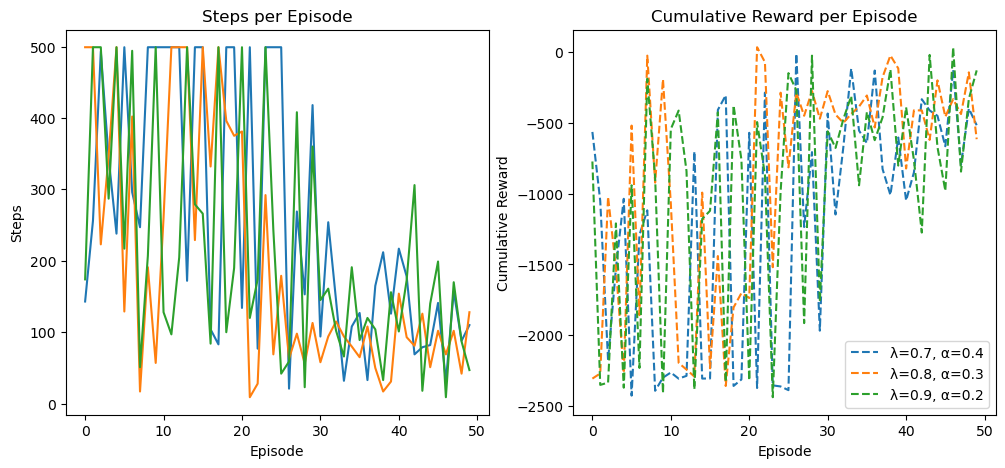

In [23]:
plt.figure(figsize=(12,5))

for i in range(len(steps)):
    plt.subplot(1,2,1).plot(steps[i], '-')
    plt.subplot(1,2,1).set_xlabel('Episode')
    plt.subplot(1,2,1).set_ylabel('Steps')
    plt.subplot(1,2,1).set_title('Steps per Episode')


    plt.subplot(1,2,2).plot(rewards[i], '--'
                            , label=f'λ={lambda_alphas[i][0]}, α={lambda_alphas[i][1]}')
    plt.subplot(1,2,2).set_xlabel('Episode')
    plt.subplot(1,2,2).set_ylabel('Cumulative Reward')
    plt.subplot(1,2,2).set_title('Cumulative Reward per Episode')

plt.legend()
plt.show

In [7]:
# Running a slower environment for better accuracy
env_lfa = Env_LFA(frequency = 1/25, n_spins=28, nF=60
                       , speed_linear = .7, speed_angular = 0.5*pi
                       , distance_reward_scaler = 1.0, rewards = [50, -10, 0, -1])

[WARN] [1715021540.028441807] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[INFO] [1715021540.036287996] [ActionPublisher_StateSubscriber]: Environment Initialised


Sarsa (online method) with eligibility trace methods were chosen for its data-efficiency. Test confirmed that both the Sarsa with eligibility trace methods tested yielded similar results; however, `trueSarsaλ` was selected due to being more efficient (space and computation) (Sutton and Barto, 2020).

Hyper-parameter tuning indicated that a combination of linear and exponential decay yielded less "noisy" results; similarly, γ=0.9 saw more consistent results in the later episodes compared to lower values.
Finally, the intermediate values of λ=0.8 and α=0.3 produced less noisy results compared to other tested combinations, which is expected as per Sutton and Barto (2020).

## Performance of Model 1

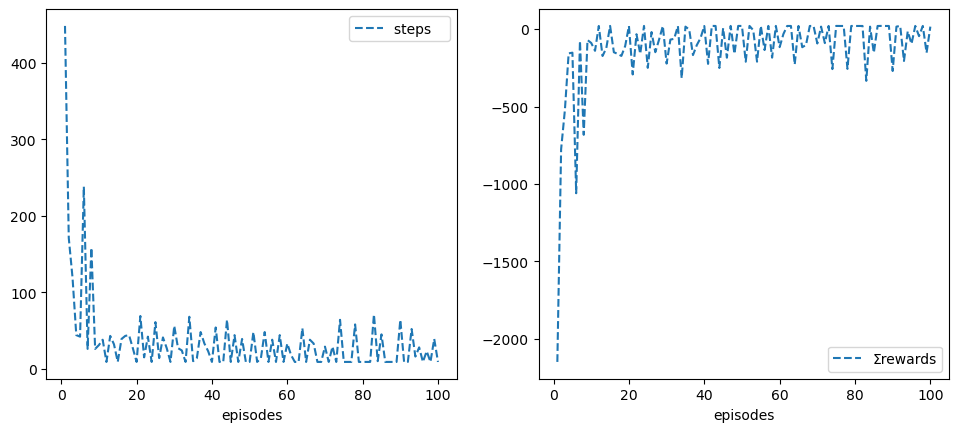

In [10]:
# Using selected hyperparameters in Model 1 selection
model1_trueSarsaλ = tracking_trueSarsaλ(env=env_lfa, max_t=1000, episodes=100, dε=.99, seed=1, γ=.9, λ=.8, α=.3, **demoGame()).interact()

In [19]:
# Success rate
n_goals_reached = model1_trueSarsaλ.env.n_achieved_goals
n_episodes = 100
percent_goals_reached = n_goals_reached/n_episodes

n_successes = len(np.where(model1_trueSarsaλ.n_wall_hits==0)[0])
success_rate = n_successes/percent_goals_reached

n_tolerant_successes = len(np.where(model1_trueSarsaλ.n_wall_hits<=1)[0])

print(f'Model 1 achieved the goal: {n_goals_reached} times ({n_goals_reached}%)')
print(f'Model 1 was "successful": {success_rate:.0f}% of the time(s)')
print(f'Number of times Model 1 reached the goal and did not hit the wall more than 1 time: {n_tolerant_successes}')

Model 1 achieved the goal: 100 times (100%)
Model 1 was "successful": 1% of the time(s)
Number of times Model 1 reached the goal and did not hit the wall more than 1 time: 42


## Discussion of results
`model1_trueSarsaλ` demonstrated strong convergence characteristics after ~15-20 episodes and remained relatively noise-free due to the decay of ε for ε-greedy action selection. This did not result in a high success rate, as only 1% of runs reached the goal without running into a wall (42% if we allow 1 wall hit).

This lack of success was due to an perplexing issue where after successfully reaching a goal, the Turtlebot was given to running straight into a wall repeatedly (~5-15 times) before then trying a different approach. Hypothesis for this phenomenon include:
1) The asynchronous nature of the messages from ROS2 meant that `/cmd_vel` messages were being issued without the Turtlebot responding; for example, upon resetting after reaching a goal, the Turtlebot would be "instructed" to "turn left", but was then instructed to "move forward" before it had finished turning left
2) Potential issues with the magnitude of reward upon reaching a goal meants that the "forward" action was associated with the most reward; this was then rectified after accruing a volume of negative reward from hitting the wall repeatedly

Model 1 was successful in its implementation, though some fine-tuning is required on its interaction with ROS2 and Gazebo.

# Section 4: Model 2
## Policy Gradient with Non-Linear Function Approximation

### Setup: Importing required modules and device testing

In [10]:
# Importing dependencies
from collections import deque
from itertools import islice
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.layers import Dense, Flatten, Input
from tensorflow.keras.losses import Huber

# Importing required classes and functions from `RLnn.py`
# Note that this overrides some of the classes and functions imported from `RL.py` and `RLv.py`
# Full notebook reset will be required once this is run
from RLnn import *

In [11]:
# Listing version of software used
print(f"tensorflow version: {tf.__version__}")
print("cudnn_version",tf.sysconfig.get_build_info()['cudnn_version'])
print("cuda_version",tf.sysconfig.get_build_info()['cuda_version'])

# Checking for device availability
print('-----------------------------------')
print(f"Number of GPU devices available: {len(tf.config.list_physical_devices('GPU'))}")
print('-----------------------------------')

tensorflow version: 2.16.1
cudnn_version 8
cuda_version 12.3
-----------------------------------
Number of GPU devices available: 1
-----------------------------------


## Model 1 Attempt 1
The first attempt inherits from the `MRP` class described in `RLnn.py`, with the core of the model taking inspiration from a tensorflow tutorial: https://www.tensorflow.org/tutorials/reinforcement_learning/actor_critic
Ultimately, this model failed as it began to shift the policy to favour one action over all others across all states. This may have been due to incorrect application of the gradients calculated in Tensorflow as varying hyperparameters in testing did not yield any materially different results.

In [12]:
class ActorCritic_NN(MRP):
    def __init__(self, α=1e-4, **kw):
        super().__init__(**kw)
        
        self.α = α

        self.huber_loss = Huber()
        #self.optimizer_actor = Adam(learning_rate=self.α)
        #self.optimizer_critic = Adam(learning_rate=self.α)
        self.optimizer = Adam(learning_rate=self.α)

        # Creating instances of neural networks
        self.actor_critic = self.create_actorcritic()

        # Overriding policy to use probabilities generated by the Actor
        self.policy = self.sample_action

    # Overriding original create_model for compatibility
    def create_model(self, net_str):
        x0 = Input(self.env.reset().shape)
        x = Dense(128, activation='relu')(x0)
        
        if      net_str == 'V':         x = Dense(1)(x)
        else:                           x = Dense(self.env.nA)(x)

        model = Model(x0, x)
        #model.compile(optimizer=Adam(self.α), loss='mse')
        #model.summary()
        model.net_str = net_str
        return model

    def create_actorcritic(self):
        inputs = Input(self.env.reset().shape)
        common = Dense(128, activation='relu')(inputs)
        actor = Dense(self.env.nA, activation="softmax")(common)
        critic = Dense(1)(common)

        return Model(inputs=inputs, outputs=[actor, critic])
    
    # Using a probabilistic action-selection policy to gradually converge on optimal action
    #   but does risk convering to incorrect action
    def sample_action(self, s):
        action, _ = self.actor_critic(s.reshape(1, -1))
        action = tf.squeeze(action).numpy().astype(np.float32)
        if self.t_ % 10 == 0: print(f's[:5]: {s[:5]} | Pr(action): {action}')
        action = np.random.choice(self.env.nA, p=action)
        return action
    
    def get_returns(self, r, gamma):
        discounted_returns = tf.TensorArray(dtype=tf.float32
                                            , size=tf.shape(r)[0])
        
        rewards = tf.cast(tf.squeeze(r)[::-1], dtype=tf.float32)        # Flipping the rewards to start from the latest reward
        disc_return = tf.constant(0.0)                                  # Return after final time-step is 0 (treat as terminal state)
        disc_return_shape = disc_return.shape                           # Saving dimension in case operations mess it up

        for i in range(rewards.shape[0]):
            reward = rewards[i]
            disc_return = reward + gamma * disc_return                  # Calculating Discounted Return
            disc_return.set_shape(disc_return_shape)                    # Restting dimension of return to scalar just in case
            discounted_returns.write(i, disc_return).mark_used()        # Placing the discounted return in position of array of returns
            
        discounted_returns = discounted_returns.stack()[::-1]           # Flipping array back so that it matchines with other batch arrays
        
        # Standardizing returns to stablise training
        #  Adding a small number to denominator to avoid div/0 error
        #discounted_returns = (discounted_returns - tf.math.reduce_mean(discounted_returns)) \
        #                        / (tf.math.reduce_std(discounted_returns) + np.finfo(np.float32).eps.item())
        return discounted_returns
    
    def save_weights(self):
        print(self.saving_msg%('critic',self.t_))
        self.actor_critic.save_weights('actor_critic.weights.h5')
        
        print(f'>> -----------Weights Saved-------------')

    def load_weights(self, net, net_str ):
        print(self.loading_msg%net_str)
        loaded_weights = net.load_weights(net_str + '.weights.h5')
        loaded_weights.assert_consumed()
        print(f'<< -----------Weights Loaded-------------')

    def online(self, s, rn, sn, done, a, an, *args):
        # Running an episode
        if self.t_%10==0:
            print(f'Exp. Step: {self.t_} | Ep: {self.ep} | Step: {self.t}: {self.env.actions_list[a]}')

        if self.t_%self.nbatch == 0 and self.t_>self.nbatch-1:
            with tf.GradientTape() as tape:
                # Update networks when we have enough data to form a batch

                print(f'---------------Updating networks----------------')
                # Retrieving batch of experiences
                (s, a, rn, sn, dones), inds = self.batch()

                # Converting to Tensors
                s = tf.cast(tf.convert_to_tensor(s), tf.float32)
                rn = tf.cast(tf.convert_to_tensor(rn.reshape(-1,1)), tf.float32)
                sn = tf.cast(tf.convert_to_tensor(sn), tf.float32)
                discounted_returns = self.get_returns(r=rn, gamma=self.γ)

                action_probs, v = self.actor_critic(s)                                      # batch of predicted state values and action probabilities

                # Calculating log probabilities of actions
                selected_actions_probs = tf.convert_to_tensor([action_probs[ind, action]    # selecting the probabilities of the actions chosen in batch
                                                    for (ind,action) in zip(inds, a)], dtype=tf.float32)

                #selected_actions_probs = tf.cast(tf.convert_to_tensor(selected_actions_probs), dtype=tf.float32)
                action_log_probs = tf.math.log(selected_actions_probs)
                
                # Calculating advantage function
                advantage = discounted_returns - tf.squeeze(v)

                print(f'Shapes: v: {v.shape}, rn: {rn.shape}, sn: {sn.shape}, action_probs: {action_probs.shape}, advantage: {advantage.shape}, \n \
                      discounted_returns: {discounted_returns.shape}, action_log_probs: {action_log_probs.shape}')
                
                loss_actor = -tf.math.reduce_sum(advantage * action_log_probs)
                loss_critic = self.huber_loss(tf.squeeze(v), discounted_returns)

                loss = loss_actor + loss_critic
                print(f'loss_actor: {loss_actor}, loss_critic: {loss_critic}, loss: {loss}')

                # Calculating gradients
                grads = tape.gradient(loss, self.actor_critic.trainable_variables)

                # Apply gradients
                self.optimizer.apply_gradients(zip(grads, self.actor_critic.trainable_variables))
                print(f'---------------Networks updated-----------------')

In [13]:
class Env_LFA_NN(Env_TurtlebotAssessment2):
    def __init__(self, nF=60, **kw):
        self.nF = nF
        super().__init__(**kw)
    
    def s_(self):
        # Discretizing to the nearest 0.1 metres
        φ = np.round(self.scans, 1)
        
        # Putting heavier weighting on the front sensors (~60 degree cone in front)
        # Assumption is that what's in front is more important than what's to the sides / back
        #front_beams = int(np.round(60/360 * self.nF, 0))
        #front_weights = 2.0     # Front beams are worth twice as much
        #φ[:front_beams//2] *= front_weights
        #φ[-front_beams//2:] *= front_weights

        return φ/self.range_max #/φ.sum()    # Normalizing features
    
    
    # Defining a one-hot encoded feature vector
    def S_(self):
        return np.eye(self.nF)

In [14]:
env_nn = Env_LFA_NN(frequency = 1/25, n_spins=15, nF=60
                       , speed_linear = .7, speed_angular = 0.5*pi
                       , distance_reward_scaler = 1., rewards = [1000, -10, 0, -1])

[WARN] [1715026885.813008901] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[INFO] [1715026885.826600475] [ActionPublisher_StateSubscriber]: Environment Initialised


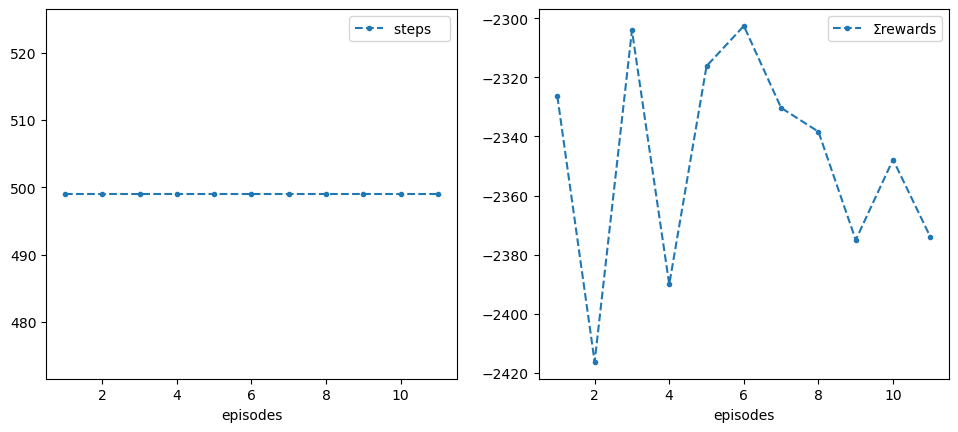

[INFO] [1715030368.382472643] [ActionPublisher_StateSubscriber]: Model Pose Reset


s[:5]: [0.62857145 0.5714286  0.37142855 0.6857143  0.71428573] | Pr(action): [5.7317206e-04 3.9195735e-03 9.9550724e-01]
Exp. Step: 5490 | Ep: 11 | Step: 0: turn right
s[:5]: [0.42857143 0.71428573 0.7428571  0.8        0.85714287] | Pr(action): [6.5957307e-04 5.0351131e-03 9.9430531e-01]
Exp. Step: 5500 | Ep: 11 | Step: 10: turn right
---------------Updating networks----------------
Shapes: v: (100, 1), rn: (100, 1), sn: (100, 60), action_probs: (100, 3), advantage: (100,), 
                       discounted_returns: (100,), action_log_probs: (100,)
loss_actor: -10.52270221710205, loss_critic: 19.96123504638672, loss: 9.438532829284668
---------------Networks updated-----------------
s[:5]: [0.7428571  0.7714286  0.82857144 0.88571423 0.8       ] | Pr(action): [8.0459093e-04 5.2938112e-03 9.9390161e-01]
Exp. Step: 5510 | Ep: 11 | Step: 20: turn right
s[:5]: [0.6857143  0.5142857  0.42857143 0.7428571  0.7714286 ] | Pr(action): [7.2268338e-04 3.9813640e-03 9.9529594e-01]
Exp. Step: 55

KeyboardInterrupt: 

In [16]:
ac_nn = ActorCritic_NN(env=env_nn, seed=1, α=.001, γ=0.6, store=True, episodes=30, max_t=500, nbuffer=500, nbatch=100, **demoGame()).interact()

## Model 1 Attempt 2
The second attempt inherits from the `MDP` class from the provided `RLnn.py`, as well as the Actor-Critic Policy Gradient example provided in `RL.py`.
This attempt also failed to show signs of convergence, though from observing the Turtlebot in the environment, it did seem to "recognise" when it had entered the "room" where the goal was present and navigated to the goal quickly; this implies that the agent struggled to recognise the location of the goal "room" and may have benefited from a more nuanced reward function as well as a higher "movement resolution" (slower movements with longer breaks), however, there was insufficient time to test this hypothesis.

In [175]:
class ActorCritic_PGNN(MDP):
    def __init__(self, create_vN=True, **kw):
        super().__init__(**kw)
        self.create_vN = create_vN
        self.policy = self.sample_action

    # Overriding provided example to work with 3 actions
    def V_(self, s, Vs=None):
        
        # update the V network if Vs is passed
        if Vs is not None: self.vN.fit(s, Vs, verbose=0); return None
        
        # predict for one state for εgreedy, or predict for a batch of states, copy to avoid auto-grad issues
        #return self.vN.predict(np.expand_dims(s, 0))[0] if len(s.shape)!=self.env.nA \
        #    else np.copy(self.vN.predict(s)) 
        return np.copy(self.vN.predict(s, verbose=0))
    
    def Q_(self, s, Qs=None):
        # update the Q networks if Qs is passed
        if Qs is not None: self.qN.fit(s, Qs, verbose=0); return None

        # predict for one state for εgreedy, or predict for a batch of states, 
        # copy to avoid auto-grad issues
        #return self.qN.predict(np.expand_dims(s, 0))[0] if len(s.shape)!=self.env.nA \
        #    else np.copy(self.qN.predict(s))
        if len(s.shape)==1: s = np.expand_dims(s,0)
        return np.copy(self.qN.predict(s, verbose=0))

    # Overriding weight save/loading methods for compatibility with TF2
    def save_weights(self):
        self.vN.save_weights(f'vN.weights.h5')
        self.qN.save_weights(f'qN.weights.h5')
        
        print(f'>> -----------Weights Saved-------------')

    def load_weights(self, net, net_str ):
        print(self.loading_msg%net_str)
        loaded_weights = net.load_weights(net_str + '.weights.h5')
        loaded_weights.assert_consumed()
        print(f'<< -----------Weights Loaded-------------')
    
    # Overriding original create_model for compatibility
    def create_model(self, net_str):
        x0 = Input(self.env.reset().shape)
        x = Dense(128, activation='relu')(x0)
        
        if      net_str == 'V':         x = Dense(1)(x)
        else:                           x = Dense(self.env.nA)(x)

        model = Model(x0, x)
        model.compile(optimizer=Adam(self.α), loss='mse')
        #model.summary()
        model.net_str = net_str
        return model
    
    def π(self, s, a=None):
        Qs = self.Q_(s)
        exp = np.squeeze(np.exp(Qs))
        return exp/exp.sum() if a is None else (exp/exp.sum())[a]
    
    # Using a probabilistic action-selection policy to gradually converge on optimal action
    #   but does risk convering to incorrect action
    def sample_action(self, s):
        action_values = np.squeeze(self.Q(s))
        exp = np.exp(action_values)
        action_probs = exp/exp.sum()        
        action = np.random.choice(self.env.nA, p=np.squeeze(action_probs))
        return action

    def discounted_returns(self, δ, γ):
        discounted_returns = np.zeros(np.squeeze(δ).shape)
        δ = np.squeeze(δ)[::-1]                                     # Flipping the rewards to start from the latest reward
        disc_return = 0                                             # Return after final time-step is 0 (treat as terminal state)

        for i in range(len(δ)):
            td_error = δ[i]
            disc_return = td_error + γ * disc_return                # Calculating Discounted Return
            discounted_returns[i] = disc_return
            
        discounted_returns = discounted_returns[::-1]       # Flipping array back so that it matchines with other batch arrays
        return discounted_returns

    def step0(self):
        self.γt = 1
    
    def online(self, s, rn, sn, done, a, *args):
        # Running an episode
        if self.t_%10==0:
            print(f'Exp. Step: {self.t_} | Ep: {self.ep} | Step: {self.t+1}: {self.env.actions_list[a]}')

        if self.t_%self.nbatch == 0 and self.t_>self.nbatch-1:
            # Update networks when we have enough data to form a batch
            π, γ, α = self.π, self.γ, self.α
            print(f'---------------Updating networks----------------')
            # Retrieving batch of experiences
            (s, a, rn, sn, dones), inds = self.batch()

            a = np.expand_dims(a,-1)
            rn = np.expand_dims(rn, -1)
            dones = np.expand_dims(dones, -1)

            print(f'Shapes>> s: {s.shape}, a: {a.shape}, rn: {rn.shape}')

            v  = self.V(s)
            vn = self.V(sn)
            q = self.Q(s)
            q = np.array([q[ind, action] for (ind, action) in zip(inds,a)])

            v_target = rn + (1- dones)*γ*vn                     # Calculate target for the critic network

            δ = v_target - v                                    # Calculate batch of td-errors
            #action_probs = np.array([self.π(np.squeeze(state), np.squeeze(action)) for (state, action) in zip(s,a)])                          # Get batch of probabilities of actions selected
            #action_probs = np.expand_dims(action_probs, 1)
            action_probs = self.π(s)

            self.V(s, v_target)
            
            discounted_returns = np.expand_dims(self.discounted_returns(δ, γ), -1)
            print(f'Shapes>> v_target: {v_target.shape}, vn: {vn.shape}')
            print(f'Shapes>> q: {q.shape}, δ: {δ.shape}, discounted_returns: {discounted_returns.shape}, action_probs.shape: {action_probs.shape}')

            q_target = q + α*discounted_returns*(1-action_probs)
            print(f'q_target.shape: {q_target.shape}')
            self.Q(s, q_target)
            
            print(f'---------------Networks updated-----------------')

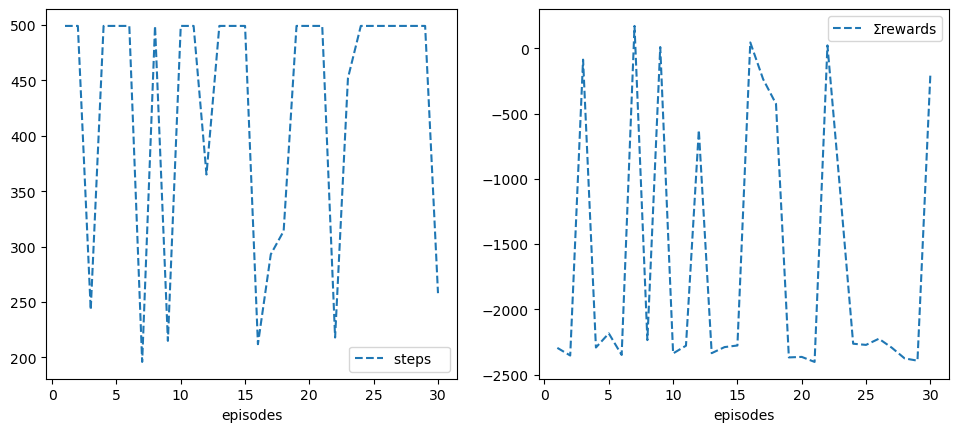

In [176]:
ac_nn = ActorCritic_PGNN(env=env_nn, seed=1, α=.001, γ=0.9, store=True, episodes=30, max_t=500, nbuffer=500, nbatch=50, **demoGame()).interact()

# Section 5: Conclusion and Reflection
Both model approaches, Linear Function Approximation and Non-Linear Function Approximation with Neural Networks, demonstrated different levels of success; the former reached "successful" convergence whilst the latter was unable to demonstrate convergence to target in the time available.

Success rates for Model 1 were depressed due to lack of fine-tuning with the reward function as well as a lack of experience with the asynchronous messaging system of ROS2 (which potentially interfered with the operation of the Turtlebot). However, overall the Linear Function Approximation method demonstrated that even with minimal feature engineering it is possible for the Turtlebot to consistently reach its goal.

Model 2 was more challenged, with longer training time and greater resources (e.g. GPU) required to train the model; this meant that experimentation and training time with the model was limited and therefore less able to explore optimal hyperparameters. However, Model 2 Attempt 2 showed some signs of learning goal recognition under specific circumstances, which hints that with further work it may reach convergence.

Finally, this assessment submission would have benefited from a more planned and targeted experimentation style; the "trial-and-error" approach taken meant that insufficient time was allocated to model training, which likely impacted success.

# References
 - Sutton, R., Barto, A. 2020. *Reinforcement Learning An Introduction*. Second Edition. Cambridge, Massachussets. The MIT Press.
 - Altahhan, A. 20204. *Various Jupyter notebooks and provided code from OCOM5205M Robotics Module*. Leeds, United Kingodom. University of Leeds.